<a href="https://colab.research.google.com/github/nileve-teo/M-todos-num-ricos/blob/main/met_20_04_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FUNCIÓN EN FORMA DE MANO

# P. LAGRANGE

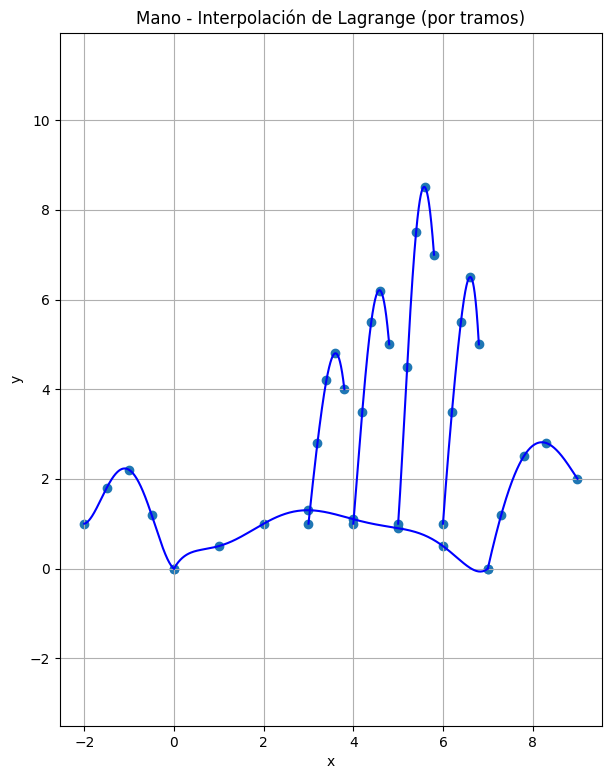

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# FUNCION LAGRANGE (vectorizada para mejor rendimiento)
# --------------------------------------------------
def lagrange(x_data, y_data, x_eval):
    x_data = np.array(x_data)
    y_data = np.array(y_data)
    n = len(x_data)
    y_eval = np.zeros_like(x_eval, dtype=float)

    for i in range(n):
        L = np.ones_like(x_eval, dtype=float)
        for j in range(n):
            if i != j:
                L *= (x_eval - x_data[j]) / (x_data[i] - x_data[j])
        y_eval += y_data[i] * L

    return y_eval

# --------------------------------------------------
# FUNCION PARA GRAFICAR TRAMOS
# --------------------------------------------------
def graficar_tramo(x, y, color='blue', label=None):
    x_vals = np.linspace(min(x), max(x), 300)
    y_vals = lagrange(x, y, x_vals)
    plt.plot(x_vals, y_vals, color=color, label=label)

# --------------------------------------------------
# DEFINICION DE LA MANO (MEJORADA)
# --------------------------------------------------

# Palma inferior
x1 = [0,1,2,3,4,5,6,7]
y1 = [0,0.5,1,1.3,1.1,0.9,0.5,0]

# Pulgar (curvado)
x2 = [7,7.3,7.8,8.3,9]
y2 = [0,1.2,2.5,2.8,2]

# Índice
x3 = [6,6.2,6.4,6.6,6.8]
y3 = [1,3.5,5.5,6.5,5]

# Medio (más alto)
x4 = [5,5.2,5.4,5.6,5.8]
y4 = [1,4.5,7.5,8.5,7]

# Anular
x5 = [4,4.2,4.4,4.6,4.8]
y5 = [1,3.5,5.5,6.2,5]

# Meñique
x6 = [3,3.2,3.4,3.6,3.8]
y6 = [1,2.8,4.2,4.8,4]

# Lado izquierdo (cierre)
x7 = [0,-0.5,-1,-1.5,-2]
y7 = [0,1.2,2.2,1.8,1]

# --------------------------------------------------
# GRAFICA
# --------------------------------------------------
plt.figure(figsize=(7,9))

graficar_tramo(x1,y1)
graficar_tramo(x2,y2)
graficar_tramo(x3,y3)
graficar_tramo(x4,y4)
graficar_tramo(x5,y5)
graficar_tramo(x6,y6)
graficar_tramo(x7,y7)

# Puntos originales
x_total = np.concatenate([x1,x2,x3,x4,x5,x6,x7])
y_total = np.concatenate([y1,y2,y3,y4,y5,y6,y7])

plt.scatter(x_total, y_total)

plt.title("Mano - Interpolación de Lagrange (por tramos)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.axis('equal')

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

# -----------------------------------
# 1. PARAMETRO
# -----------------------------------
n_puntos = 50
t = np.linspace(0, 1, n_puntos)

# -----------------------------------
# 2. DEFINIR FORMA DE MANO (MEJORADA)
# -----------------------------------
# Palma + dedos (forma manual)
x = np.array([
0,1,2,3,4,5,6,7,8,9,
9,8.5,8,7.5,7,
6.8,6.6,6.4,6.2,6,
5.8,5.6,5.4,5.2,5,
4.8,4.6,4.4,4.2,4,
3.8,3.6,3.4,3.2,3,
2.5,2,1.5,1,0,-1,-2,0,1,2,3,4
])

y = np.array([
0,0.5,1,1.3,1.2,1,0.8,0.5,0.2,0,
2,3,4,3,2,
5,6,5.5,4,1,
7,8,7.5,5,1,
5,6,5.5,3.5,1,
4,4.8,4.2,2.8,1,
0.8,0.5,0.3,0.2,0,1,1.5,0,0.2,0.5,0.8,1
])

# Ajustar tamaño exacto a 50 puntos
x = x[:50]
y = y[:50]

# -----------------------------------
# 3. INTERPOLACION DE LAGRANGE
# -----------------------------------
pol_x = lagrange(t, x)
pol_y = lagrange(t, y)

# -----------------------------------
# 4. EVALUACION
# -----------------------------------
t_suave = np.linspace(0, 1, 500)
x_suave = pol_x(t_suave)
y_suave = pol_y(t_suave)

# -----------------------------------
# 5. GRAFICA
# -----------------------------------
plt.figure(figsize=(6,8))

plt.plot(x_suave, y_suave, label="Lagrange", linewidth=2)
plt.scatter(x, y, color='red', s=15, label="Puntos")

plt.title("Interpolación de Lagrange (Mano Paramétrica)")
plt.axis('equal')
plt.grid()
plt.legend()

plt.show()

IndexError: index 47 is out of bounds for axis 0 with size 47

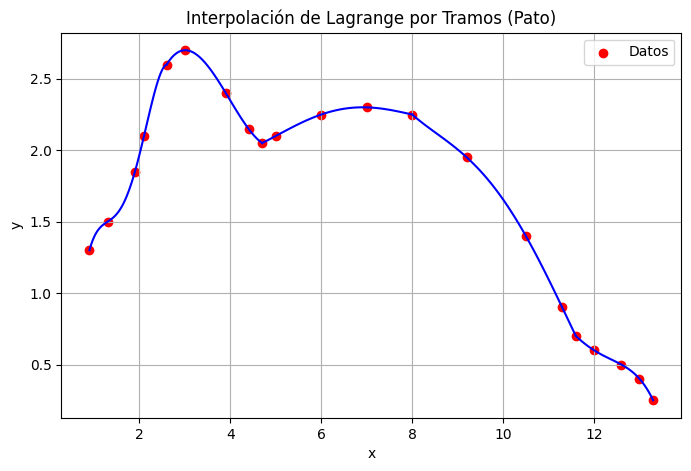

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# FUNCION LAGRANGE
# -----------------------------
def lagrange(x_data, y_data, x_eval):
    n = len(x_data)
    y_eval = np.zeros_like(x_eval, dtype=float)

    for i in range(n):
        L = np.ones_like(x_eval, dtype=float)
        for j in range(n):
            if i != j:
                L *= (x_eval - x_data[j]) / (x_data[i] - x_data[j])
        y_eval += y_data[i] * L

    return y_eval

# -----------------------------
# DATOS DEL PATO (PARTE SUPERIOR)
# -----------------------------
x = np.array([0.9,1.3,1.9,2.1,2.6,3,3.9,4.4,4.7,5,6,7,8,9.2,10.5,11.3,11.6,12,12.6,13,13.3])
y = np.array([1.3,1.5,1.85,2.1,2.6,2.7,2.4,2.15,2.05,2.1,2.25,2.3,2.25,1.95,1.4,0.9,0.7,0.6,0.5,0.4,0.25])

# -----------------------------
# INTERPOLACION POR TRAMOS
# -----------------------------
plt.figure(figsize=(8,5))

bloque = 5  # tamaño del tramo (clave para evitar oscilaciones)

for i in range(0, len(x)-bloque+1, bloque-1):
    x_sub = x[i:i+bloque]
    y_sub = y[i:i+bloque]

    x_vals = np.linspace(min(x_sub), max(x_sub), 100)
    y_vals = lagrange(x_sub, y_sub, x_vals)

    plt.plot(x_vals, y_vals, 'b')

# puntos originales
plt.scatter(x, y, color='red', label='Datos')

plt.title("Interpolación de Lagrange por Tramos (Pato)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()

plt.show()

/tmp/ipykernel_50552/3282698929.py:15: RuntimeWarning: divide by zero encountered in divide
  L *= (x_eval - x_data[j]) / (x_data[i] - x_data[j])
/tmp/ipykernel_50552/3282698929.py:15: RuntimeWarning: invalid value encountered in divide
  L *= (x_eval - x_data[j]) / (x_data[i] - x_data[j])
/tmp/ipykernel_50552/3282698929.py:15: RuntimeWarning: invalid value encountered in multiply
  L *= (x_eval - x_data[j]) / (x_data[i] - x_data[j])
/tmp/ipykernel_50552/3282698929.py:16: RuntimeWarning: invalid value encountered in multiply
  y_eval += y_data[i] * L


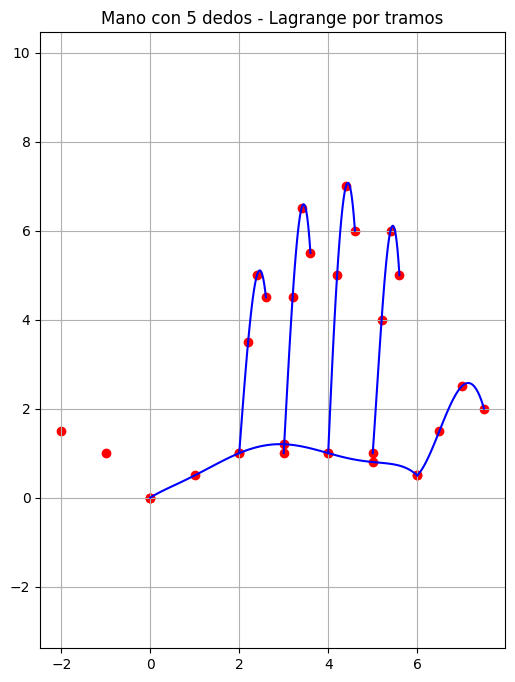

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# FUNCION LAGRANGE
# -----------------------------
def lagrange(x_data, y_data, x_eval):
    n = len(x_data)
    y_eval = np.zeros_like(x_eval, dtype=float)

    for i in range(n):
        L = np.ones_like(x_eval, dtype=float)
        for j in range(n):
            if i != j:
                L *= (x_eval - x_data[j]) / (x_data[i] - x_data[j])
        y_eval += y_data[i] * L

    return y_eval

# -----------------------------
# DEFINICION DE LA MANO (POR TRAMOS)
# -----------------------------

# Palma
x1 = np.array([0,1,2,3,4,5,6])
y1 = np.array([0,0.5,1,1.2,1,0.8,0.5])

# Pulgar
x2 = np.array([6,6.5,7,7.5])
y2 = np.array([0.5,1.5,2.5,2])

# Dedo 1
x3 = np.array([5,5.2,5.4,5.6])
y3 = np.array([1,4,6,5])

# Dedo 2
x4 = np.array([4,4.2,4.4,4.6])
y4 = np.array([1,5,7,6])

# Dedo 3
x5 = np.array([3,3.2,3.4,3.6])
y5 = np.array([1,4.5,6.5,5.5])

# Dedo 4
x6 = np.array([2,2.2,2.4,2.6])
y6 = np.array([1,3.5,5,4.5])

# Cierre lateral
x7 = np.array([0,-1,-2,0])
y7 = np.array([0,1,1.5,0])

# -----------------------------
# FUNCION PARA GRAFICAR
# -----------------------------
def dibujar_tramo(x, y):
    x_vals = np.linspace(min(x), max(x), 100)
    y_vals = lagrange(x, y, x_vals)
    plt.plot(x_vals, y_vals, 'b')

# -----------------------------
# GRAFICA
# -----------------------------
plt.figure(figsize=(6,8))

dibujar_tramo(x1,y1)
dibujar_tramo(x2,y2)
dibujar_tramo(x3,y3)
dibujar_tramo(x4,y4)
dibujar_tramo(x5,y5)
dibujar_tramo(x6,y6)
dibujar_tramo(x7,y7)

# puntos
plt.scatter(
    np.concatenate([x1,x2,x3,x4,x5,x6,x7]),
    np.concatenate([y1,y2,y3,y4,y5,y6,y7]),
    color='red'
)

plt.title("Mano con 5 dedos - Lagrange por tramos")
plt.axis('equal')
plt.grid()

plt.show()

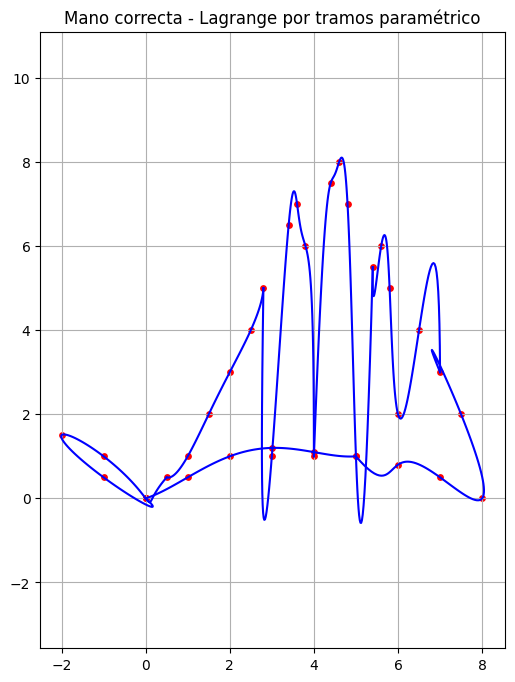

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# LAGRANGE
# -----------------------------
def lagrange(t_data, f_data, t_eval):
    n = len(t_data)
    result = np.zeros_like(t_eval, dtype=float)

    for i in range(n):
        L = np.ones_like(t_eval)
        for j in range(n):
            if i != j:
                L *= (t_eval - t_data[j]) / (t_data[i] - t_data[j])
        result += f_data[i] * L

    return result

# -----------------------------
# PUNTOS REALES (CONTORNO ORDENADO)
# -----------------------------
x = np.array([
0,1,2,3,4,5,6,7,8,
7.5,7,6.5,6,
5.8,5.6,5.4,5,
4.8,4.6,4.4,4,
3.8,3.6,3.4,3,
2.8,2.5,2,1.5,1,
0.5,0,-1,-2,-1,0
])

y = np.array([
0,0.5,1,1.2,1.1,1,0.8,0.5,0,
2,3,4,2,
5,6,5.5,1,
7,8,7.5,1,
6,7,6.5,1,
5,4,3,2,1,
0.5,0,1,1.5,0.5,0
])

# -----------------------------
# DIVIDIR EN TRAMOS
# -----------------------------
def graficar_tramos(x, y, tamaño=6):
    for i in range(0, len(x)-tamaño+1, tamaño-1):
        x_sub = x[i:i+tamaño]
        y_sub = y[i:i+tamaño]

        t = np.linspace(0, 1, len(x_sub))
        t_vals = np.linspace(0, 1, 100)

        x_vals = lagrange(t, x_sub, t_vals)
        y_vals = lagrange(t, y_sub, t_vals)

        plt.plot(x_vals, y_vals, 'b')

# -----------------------------
# GRAFICA
# -----------------------------
plt.figure(figsize=(6,8))

graficar_tramos(x, y, tamaño=6)

plt.scatter(x, y, color='red', s=15)

plt.title("Mano correcta - Lagrange por tramos paramétrico")
plt.axis('equal')
plt.grid()

plt.show()

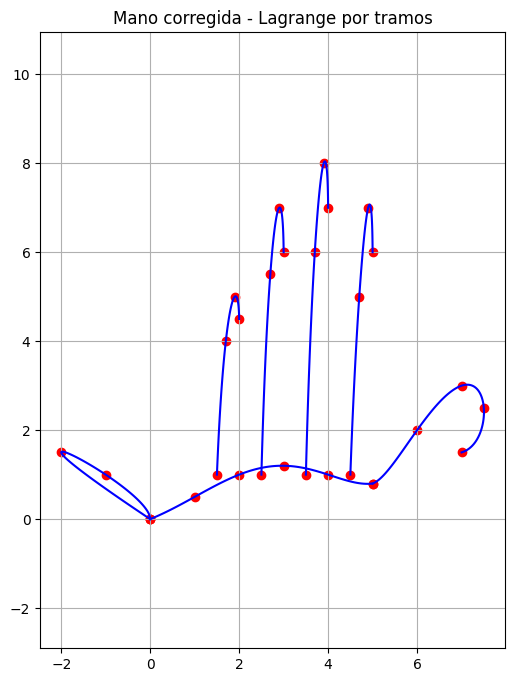

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# LAGRANGE
# -----------------------------
def lagrange(t_data, f_data, t_eval):
    n = len(t_data)
    result = np.zeros_like(t_eval, dtype=float)

    for i in range(n):
        L = np.ones_like(t_eval)
        for j in range(n):
            if i != j:
                L *= (t_eval - t_data[j]) / (t_data[i] - t_data[j])
        result += f_data[i] * L

    return result

# -----------------------------
# FUNCION PARA GRAFICAR TRAMOS PARAMETRICOS
# -----------------------------
def dibujar_tramo(x, y):
    t = np.linspace(0, 1, len(x))
    t_vals = np.linspace(0, 1, 100)

    x_vals = lagrange(t, x, t_vals)
    y_vals = lagrange(t, y, t_vals)

    plt.plot(x_vals, y_vals, 'b')

# -----------------------------
# DEFINICION CORRECTA DE LA MANO
# -----------------------------

# Palma
x_palma = [0,1,2,3,4,5]
y_palma = [0,0.5,1,1.2,1,0.8]

# Pulgar
x_pulgar = [5,6,7,7.5,7]
y_pulgar = [0.8,2,3,2.5,1.5]

# Dedo 1
x_d1 = [4.5,4.7,4.9,5]
y_d1 = [1,5,7,6]

# Dedo 2
x_d2 = [3.5,3.7,3.9,4]
y_d2 = [1,6,8,7]

# Dedo 3
x_d3 = [2.5,2.7,2.9,3]
y_d3 = [1,5.5,7,6]

# Dedo 4
x_d4 = [1.5,1.7,1.9,2]
y_d4 = [1,4,5,4.5]

# Lado izquierdo (cierre)
x_cierre = [0,-1,-2,0]
y_cierre = [0,1,1.5,0]

# -----------------------------
# GRAFICA
# -----------------------------
plt.figure(figsize=(6,8))

dibujar_tramo(x_palma, y_palma)
dibujar_tramo(x_pulgar, y_pulgar)
dibujar_tramo(x_d1, y_d1)
dibujar_tramo(x_d2, y_d2)
dibujar_tramo(x_d3, y_d3)
dibujar_tramo(x_d4, y_d4)
dibujar_tramo(x_cierre, y_cierre)

# puntos
plt.scatter(
    x_palma + x_pulgar + x_d1 + x_d2 + x_d3 + x_d4 + x_cierre,
    y_palma + y_pulgar + y_d1 + y_d2 + y_d3 + y_d4 + y_cierre,
    color='red'
)

plt.title("Mano corregida - Lagrange por tramos")
plt.axis('equal')
plt.grid()

plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# cargar imagen (CAMBIA EL NOMBRE)
img = cv2.imread('mano.png')

# verificación
if img is None:
    print("ERROR: la imagen no se cargó")
else:
    print("Imagen cargada correctamente")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)

    ys, xs = np.where(thresh == 255)
    ys = -ys

    plt.scatter(xs, ys, s=5)
    plt.axis('equal')
    plt.show()

ERROR: la imagen no se cargó


In [ ]:
import cv2
import numpy as np

# Cargar la imagen en escala de grises
img = cv2.imread('mano_puntos.png', 0)

# Aplicar un umbral para identificar solo los puntos blancos
_, thresh = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY)

# Encontrar los contornos de los puntos
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print("ID | Coordenada X | Coordenada Y")
print("-" * 30)

for i, cnt in enumerate(contours):
    # Calcular el centro del punto
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
        print(f"{i+1:02d} | {cX:12d} | {cY:12d}")


ID | Coordenada X | Coordenada Y
------------------------------


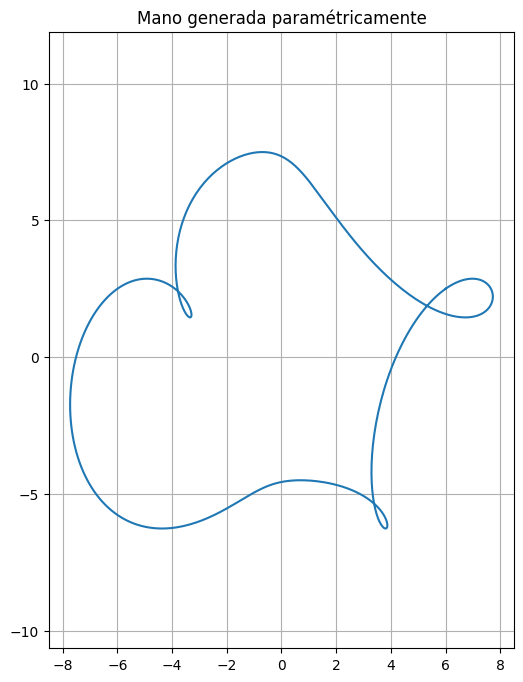

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def mano_parametrica(t):
    # contorno tipo mano (forma cerrada)
    x = (6*np.cos(t)
         + 1.5*np.sin(3*t)
         + 0.8*np.sin(5*t))

    y = (6*np.sin(t)
         + 2*np.cos(4*t)
         + 0.5*np.cos(6*t))

    return x, y

# parametro
t = np.linspace(0, 2*np.pi, 500)

x, y = mano_parametrica(t)

# grafica
plt.figure(figsize=(6,8))
plt.plot(x, y)
plt.axis('equal')
plt.grid()
plt.title("Mano generada paramétricamente")
plt.show()

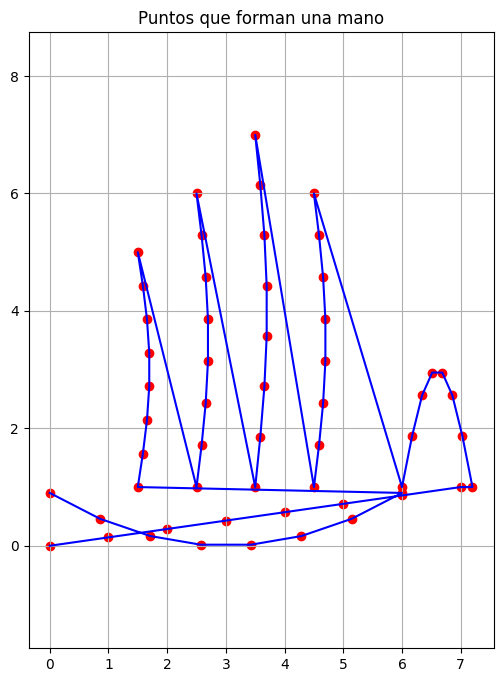

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generar_mano(n_por_tramo=8):
    x_total = []
    y_total = []

    # -------------------------
    # PALMA
    # -------------------------
    x = np.linspace(0, 6, n_por_tramo)
    y = 0.3*(x-3)**2/3
    x_total.extend(x)
    y_total.extend(y)

    # -------------------------
    # DEDO 1 (meñique)
    # -------------------------
    t = np.linspace(0, 1, n_por_tramo)
    x = 1.5 + 0.2*np.sin(np.pi*t)
    y = 1 + 4*t
    x_total.extend(x)
    y_total.extend(y)

    # -------------------------
    # DEDO 2
    # -------------------------
    t = np.linspace(0, 1, n_por_tramo)
    x = 2.5 + 0.2*np.sin(np.pi*t)
    y = 1 + 5*t
    x_total.extend(x)
    y_total.extend(y)

    # -------------------------
    # DEDO 3 (medio)
    # -------------------------
    t = np.linspace(0, 1, n_por_tramo)
    x = 3.5 + 0.2*np.sin(np.pi*t)
    y = 1 + 6*t
    x_total.extend(x)
    y_total.extend(y)

    # -------------------------
    # DEDO 4
    # -------------------------
    t = np.linspace(0, 1, n_por_tramo)
    x = 4.5 + 0.2*np.sin(np.pi*t)
    y = 1 + 5*t
    x_total.extend(x)
    y_total.extend(y)

    # -------------------------
    # PULGAR
    # -------------------------
    t = np.linspace(0, 1, n_por_tramo)
    x = 6 + 1.2*t
    y = 1 + 2*np.sin(np.pi*t)
    x_total.extend(x)
    y_total.extend(y)

    # -------------------------
    # CIERRE LATERAL
    # -------------------------
    x = np.linspace(7, 0, n_por_tramo)
    y = np.linspace(1, 0, n_por_tramo)
    x_total.extend(x)
    y_total.extend(y)

    return np.array(x_total), np.array(y_total)

# ---------------------------------
# GENERAR Y GRAFICAR
# ---------------------------------
x, y = generar_mano(8)

plt.figure(figsize=(6,8))
plt.scatter(x, y, color='red')
plt.plot(x, y, 'b')
plt.title("Puntos que forman una mano")
plt.axis('equal')
plt.grid()
plt.show()

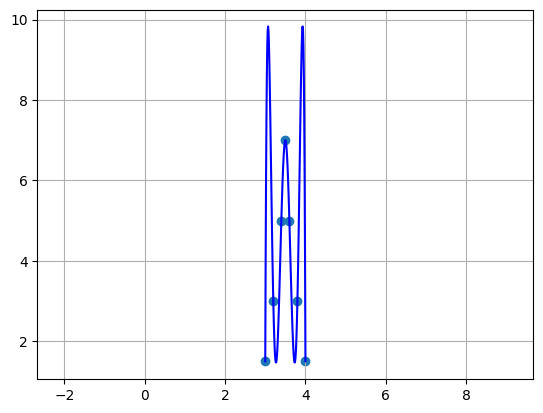

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def lagrange(x_data, y_data, x_eval):
    n = len(x_data)
    y_eval = np.zeros_like(x_eval, dtype=float)

    for i in range(n):
        L = np.ones_like(x_eval)
        for j in range(n):
            if i != j:
                L *= (x_eval - x_data[j]) / (x_data[i] - x_data[j])
        y_eval += y_data[i] * L

    return y_eval

def graficar_tramo(x, y):
    x_vals = np.linspace(min(x), max(x), 100)
    y_vals = lagrange(x, y, x_vals)
    plt.plot(x_vals, y_vals, 'b')

# EJEMPLO: dedo medio
x = np.array([3,3.2,3.4,3.5,3.6,3.8,4])
y = np.array([1.5,3,5,7,5,3,1.5])

graficar_tramo(x,y)
plt.scatter(x,y)
plt.axis('equal')
plt.grid()
plt.show()

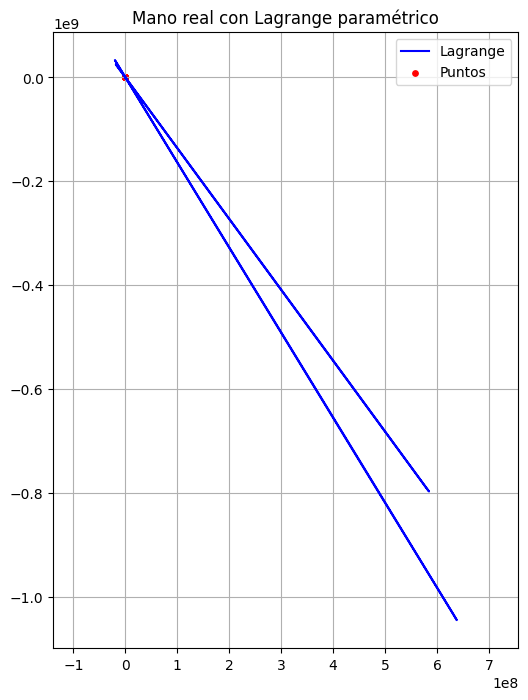

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# TUS DATOS (CORREGIDOS)
# -----------------------------
x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# -----------------------------
# PARAMETRO t
# -----------------------------
t = np.linspace(0,1,len(x))
t_vals = np.linspace(0,1,500)

# -----------------------------
# LAGRANGE PARAMETRICO
# -----------------------------
def lagrange(t_data, f_data, t_eval):
    n = len(t_data)
    result = np.zeros_like(t_eval, dtype=float)

    for i in range(n):
        L = np.ones_like(t_eval)
        for j in range(n):
            if i != j:
                L *= (t_eval - t_data[j]) / (t_data[i] - t_data[j])
        result += f_data[i] * L

    return result

x_vals = lagrange(t, x, t_vals)
y_vals = lagrange(t, y, t_vals)

# -----------------------------
# GRAFICA
# -----------------------------
plt.figure(figsize=(6,8))

plt.plot(x_vals, y_vals, 'b', label="Lagrange")
plt.scatter(x, y, color='red', s=15, label="Puntos")

plt.title("Mano real con Lagrange paramétrico")
plt.axis('equal')
plt.grid()
plt.legend()

plt.show()

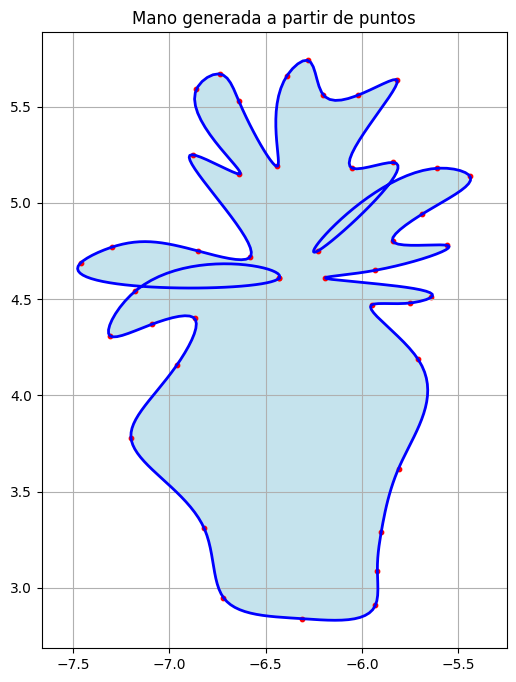

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev

# -----------------------------
# TUS DATOS
# -----------------------------
x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# -----------------------------
# ORDENAR LOS PUNTOS (CLAVE)
# -----------------------------
centro_x = np.mean(x)
centro_y = np.mean(y)

angulos = np.arctan2(y - centro_y, x - centro_x)
orden = np.argsort(angulos)

x_ord = x[orden]
y_ord = y[orden]

# cerrar la figura
x_ord = np.append(x_ord, x_ord[0])
y_ord = np.append(y_ord, y_ord[0])

# -----------------------------
# INTERPOLACIÓN SUAVE (SPLINE)
# -----------------------------
tck, u = splprep([x_ord, y_ord], s=0, per=True)
u_fino = np.linspace(0, 1, 500)

x_suave, y_suave = splev(u_fino, tck)

# -----------------------------
# GRAFICAR
# -----------------------------
plt.figure(figsize=(6,8))

plt.fill(x_suave, y_suave, color='lightblue', alpha=0.7)  # relleno tipo mano
plt.plot(x_suave, y_suave, 'b', linewidth=2)
plt.scatter(x_ord, y_ord, color='red', s=10)

plt.title("Mano generada a partir de puntos")
plt.axis('equal')
plt.grid()

plt.show()

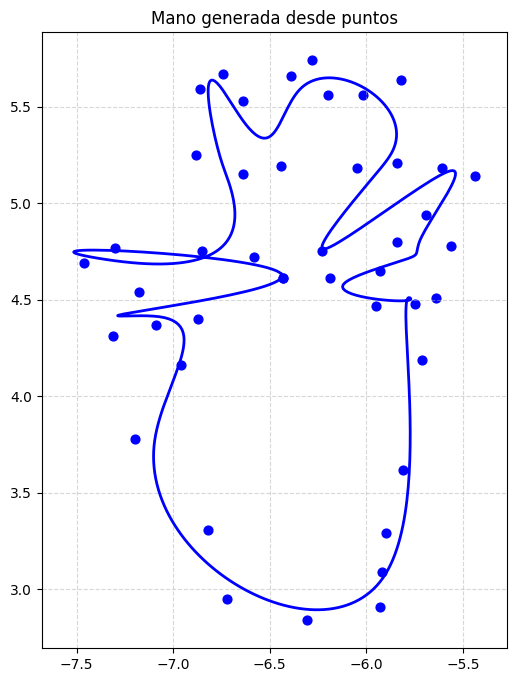

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev

# -----------------------------
# TUS DATOS
# -----------------------------
x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# -----------------------------
# ORDENAR LOS PUNTOS (CLAVE)
# -----------------------------
centro_x = np.mean(x)
centro_y = np.mean(y)

ang = np.arctan2(y - centro_y, x - centro_x)
orden = np.argsort(ang)

x_ord = x[orden]
y_ord = y[orden]

# cerrar figura
x_ord = np.append(x_ord, x_ord[0])
y_ord = np.append(y_ord, y_ord[0])

# -----------------------------
# SPLINE SUAVE
# -----------------------------
tck, u = splprep([x_ord, y_ord], s=0.5, per=True)
u_fino = np.linspace(0, 1, 500)

x_suave, y_suave = splev(u_fino, tck)

# -----------------------------
# GRAFICA ESTILO IMAGEN
# -----------------------------
plt.figure(figsize=(6,8))

# curva
plt.plot(x_suave, y_suave, color='blue', linewidth=2)

# puntos grandes tipo nodos
plt.scatter(x_ord, y_ord, color='blue', s=40)

# estilo tipo cuadriculado
plt.grid(True, linestyle='--', alpha=0.5)

plt.title("Mano generada desde puntos")
plt.axis('equal')

plt.show()

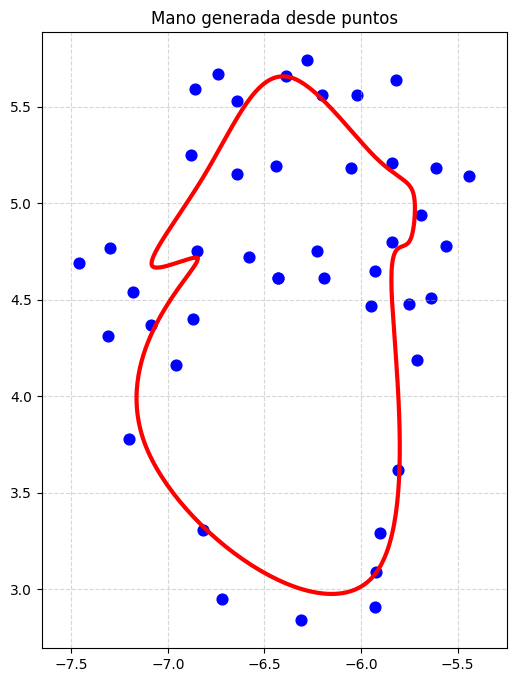

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev

# -----------------------------
# DATOS (tus puntos)
# -----------------------------
x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# -----------------------------
# ORDENAR LOS PUNTOS (clave)
# -----------------------------
centro_x = np.mean(x)
centro_y = np.mean(y)

angulos = np.arctan2(y - centro_y, x - centro_x)
orden = np.argsort(angulos)

x_ord = x[orden]
y_ord = y[orden]

# cerrar contorno
x_ord = np.append(x_ord, x_ord[0])
y_ord = np.append(y_ord, y_ord[0])

# -----------------------------
# SPLINE SUAVE (ajusta s)
# -----------------------------
tck, u = splprep([x_ord, y_ord], s=2.5, per=True)

u_fino = np.linspace(0, 1, 500)
x_suave, y_suave = splev(u_fino, tck)

# -----------------------------
# GRAFICAR
# -----------------------------
plt.figure(figsize=(6,8))

# curva tipo dibujo
plt.plot(x_suave, y_suave, color='red', linewidth=3)

# puntos tipo nodos
plt.scatter(x_ord, y_ord, color='blue', s=60)

# estilo como tu imagen
plt.grid(True, linestyle='--', alpha=0.5)

plt.title("Mano generada desde puntos")
plt.axis('equal')

plt.show()

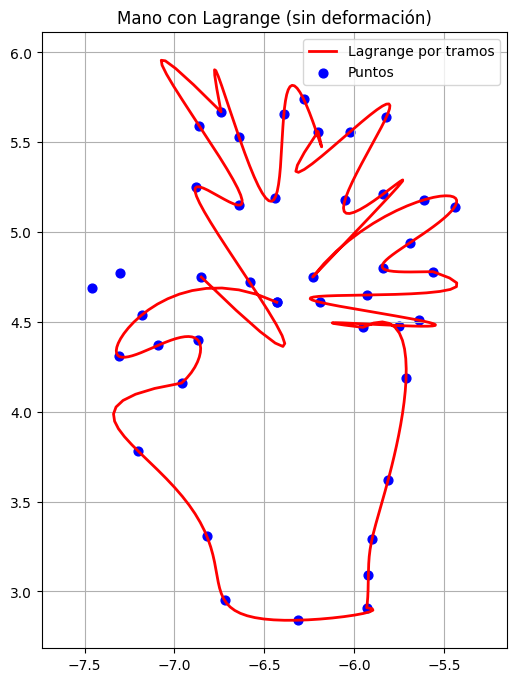

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# TUS DATOS
# -----------------------------
x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# -----------------------------
# ORDENAR PUNTOS
# -----------------------------
centro_x = np.mean(x)
centro_y = np.mean(y)

ang = np.arctan2(y - centro_y, x - centro_x)
orden = np.argsort(ang)

x = x[orden]
y = y[orden]

# cerrar figura
x = np.append(x, x[0])
y = np.append(y, y[0])

# -----------------------------
# FUNCION LAGRANGE
# -----------------------------
def lagrange(t_data, f_data, t_eval):
    n = len(t_data)
    result = np.zeros_like(t_eval, dtype=float)

    for i in range(n):
        L = np.ones_like(t_eval)
        for j in range(n):
            if i != j:
                L *= (t_eval - t_data[j]) / (t_data[i] - t_data[j])
        result += f_data[i] * L

    return result

# -----------------------------
# LAGRANGE POR TRAMOS (CLAVE)
# -----------------------------
def lagrange_tramos(x, y, tam_tramo=6):
    X_total = []
    Y_total = []

    n = len(x)

    for i in range(0, n - tam_tramo, tam_tramo - 1):
        x_sub = x[i:i+tam_tramo]
        y_sub = y[i:i+tam_tramo]

        t = np.linspace(0, 1, len(x_sub))
        t_vals = np.linspace(0, 1, 50)

        x_vals = lagrange(t, x_sub, t_vals)
        y_vals = lagrange(t, y_sub, t_vals)

        X_total.extend(x_vals)
        Y_total.extend(y_vals)

    return np.array(X_total), np.array(Y_total)

# -----------------------------
# GENERAR CURVA
# -----------------------------
x_lag, y_lag = lagrange_tramos(x, y, tam_tramo=6)

# -----------------------------
# GRAFICA
# -----------------------------
plt.figure(figsize=(6,8))

plt.plot(x_lag, y_lag, color='red', linewidth=2, label="Lagrange por tramos")
plt.scatter(x, y, color='blue', s=40, label="Puntos")

plt.title("Mano con Lagrange (sin deformación)")
plt.axis('equal')
plt.grid()
plt.legend()

plt.show()

# P. NEWTON

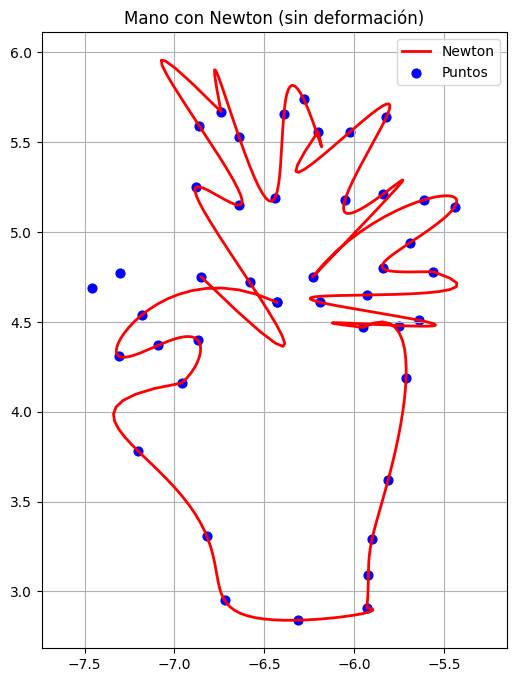

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# TUS DATOS
# -----------------------------
x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# -----------------------------
# ORDENAR
# -----------------------------
cx, cy = np.mean(x), np.mean(y)
ang = np.arctan2(y - cy, x - cx)
idx = np.argsort(ang)

x = x[idx]
y = y[idx]

# cerrar figura
x = np.append(x, x[0])
y = np.append(y, y[0])

# -----------------------------
# NEWTON (DIFERENCIAS DIVIDIDAS)
# -----------------------------
def coef_newton(t, f):
    n = len(t)
    coef = np.copy(f)

    for j in range(1, n):
        coef[j:n] = (coef[j:n] - coef[j-1:n-1]) / (t[j:n] - t[0:n-j])

    return coef

def evaluar_newton(t_data, coef, t):
    n = len(coef)
    p = np.zeros_like(t, dtype=float)

    for i in range(len(t)):
        val = coef[n-1]
        for k in range(n-2, -1, -1):
            val = val * (t[i] - t_data[k]) + coef[k]
        p[i] = val

    return p

# -----------------------------
# NEWTON POR TRAMOS
# -----------------------------
def newton_tramos(x, y, tam=6):
    X_total, Y_total = [], []

    n = len(x)

    for i in range(0, n - tam, tam - 1):
        x_sub = x[i:i+tam]
        y_sub = y[i:i+tam]

        t = np.linspace(0, 1, len(x_sub))
        t_eval = np.linspace(0, 1, 50)

        coef_x = coef_newton(t, x_sub)
        coef_y = coef_newton(t, y_sub)

        x_vals = evaluar_newton(t, coef_x, t_eval)
        y_vals = evaluar_newton(t, coef_y, t_eval)

        X_total.extend(x_vals)
        Y_total.extend(y_vals)

    return np.array(X_total), np.array(Y_total)

# -----------------------------
# GENERAR CURVA
# -----------------------------
x_new, y_new = newton_tramos(x, y, tam=6)

# -----------------------------
# GRAFICA
# -----------------------------
plt.figure(figsize=(6,8))

plt.plot(x_new, y_new, 'r', linewidth=2, label='Newton')
plt.scatter(x, y, color='blue', s=40, label='Puntos')

plt.title("Mano con Newton (sin deformación)")
plt.axis('equal')
plt.grid()
plt.legend()

plt.show()

# P. MATRICIAL

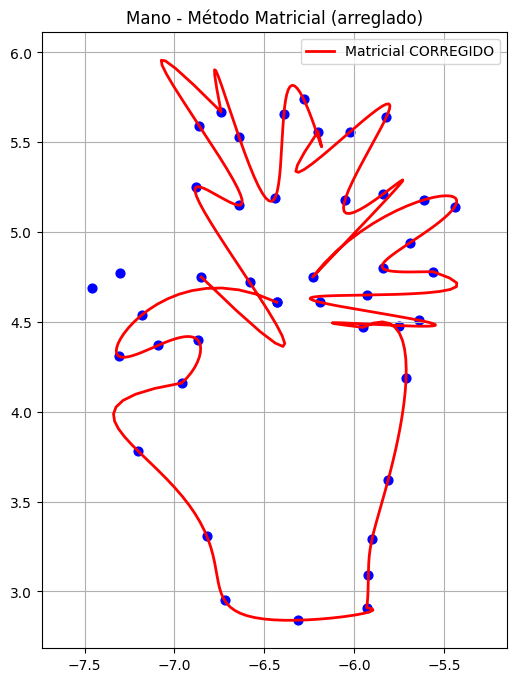

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# DATOS
# -----------------------------
x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# -----------------------------
# ORDENAR
# -----------------------------
cx, cy = np.mean(x), np.mean(y)
ang = np.arctan2(y - cy, x - cx)
idx = np.argsort(ang)

x = x[idx]
y = y[idx]

# cerrar figura
x = np.append(x, x[0])
y = np.append(y, y[0])

# -----------------------------
# VANDERMONDE CORRECTA
# -----------------------------
def vandermonde(t, grado):
    return np.vander(t, N=grado, increasing=True)

# -----------------------------
# METODO MATRICIAL POR TRAMOS
# -----------------------------
def matricial_tramos(x, y, tam=6):
    X_total, Y_total = [], []

    n = len(x)

    for i in range(0, n - tam, tam - 1):
        x_sub = x[i:i+tam]
        y_sub = y[i:i+tam]

        t = np.linspace(0, 1, len(x_sub))
        t_eval = np.linspace(0, 1, 50)

        grado = len(t)

        # matriz correcta
        V = vandermonde(t, grado)

        # resolver
        coef_x = np.linalg.solve(V, x_sub)
        coef_y = np.linalg.solve(V, y_sub)

        # evaluar (MISMO grado)
        V_eval = vandermonde(t_eval, grado)

        x_vals = V_eval @ coef_x
        y_vals = V_eval @ coef_y

        X_total.extend(x_vals)
        Y_total.extend(y_vals)

    return np.array(X_total), np.array(Y_total)

# -----------------------------
# GENERAR CURVA
# -----------------------------
x_mat, y_mat = matricial_tramos(x, y, tam=6)

# -----------------------------
# GRAFICA
# -----------------------------
plt.figure(figsize=(6,8))

plt.plot(x_mat, y_mat, 'r', linewidth=2, label='Matricial CORREGIDO')
plt.scatter(x, y, color='blue', s=40)

plt.title("Mano - Método Matricial (arreglado)")
plt.axis('equal')
plt.grid()
plt.legend()

plt.show()

# SPLINE CÚBICO

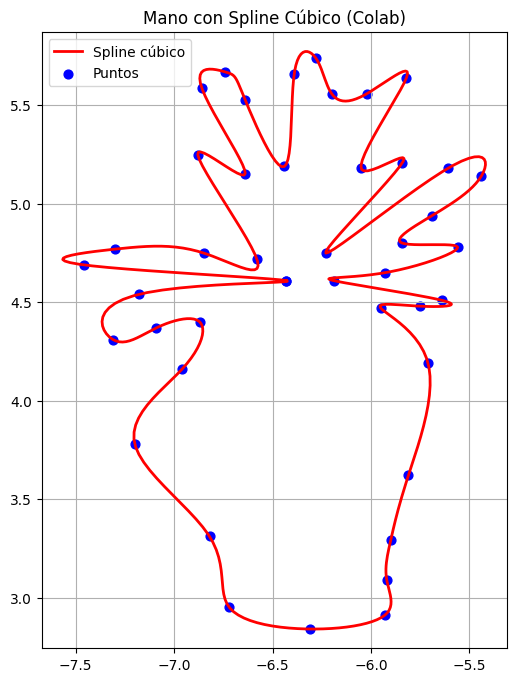

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# -----------------------------
# TUS DATOS
# -----------------------------
x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# -----------------------------
# ORDENAR PUNTOS
# -----------------------------
cx, cy = np.mean(x), np.mean(y)
ang = np.arctan2(y - cy, x - cx)
orden = np.argsort(ang)

x = x[orden]
y = y[orden]

# cerrar figura
x = np.append(x, x[0])
y = np.append(y, y[0])

# -----------------------------
# PARAMETRO t
# -----------------------------
t = np.linspace(0, 1, len(x))

# -----------------------------
# SPLINE CÚBICO PERIÓDICO
# -----------------------------
cs_x = CubicSpline(t, x, bc_type='periodic')
cs_y = CubicSpline(t, y, bc_type='periodic')

t_suave = np.linspace(0, 1, 500)

x_s = cs_x(t_suave)
y_s = cs_y(t_suave)

# -----------------------------
# GRAFICA
# -----------------------------
plt.figure(figsize=(6,8))

plt.plot(x_s, y_s, 'r', linewidth=2, label='Spline cúbico')
plt.scatter(x, y, color='blue', s=40, label='Puntos')

plt.title("Mano con Spline Cúbico (Colab)")
plt.axis('equal')
plt.grid()
plt.legend()

plt.show()

# PREGUNTA
#

Responde a las preguntas por qué el método de Lagrange, Newton y matricial no responden bien.
¿Por qué el método de splines cúbicos lo hace bien?